# Week 4 Activity: Sample Answers

This notebook shows one reasonable way to complete the worksheet. It is not the only correct analysis.


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

project_dir = Path("..").resolve()
data_path = project_dir / "data" / "clean" / "store_week_clean.csv"
output_dir = project_dir / "output"
output_dir.mkdir(parents=True, exist_ok=True)


## Part 1: First Look

One plausible summary is that this is a cleaned store-week panel with sales, staffing, wages, promotions, and store descriptors.


In [3]:
df = pd.read_csv(data_path)

df.head()


,week,store_id,store_type,region,promotion_flag,total_hours,avg_hourly_pay,weekly_sales,staffing_model
0,2025-01-05,CB01,CBD,North,Yes,38.0,39.00,10056.0,Heavy
1,2025-01-12,CB01,CBD,North,No,38.0,36.51,9786.0,Heavy
2,2025-01-19,CB01,CBD,North,No,29.0,36.50,7888.0,Standard
3,2025-01-26,CB01,CBD,North,No,37.0,37.00,10542.0,Heavy
4,2025-02-02,CB01,CBD,North,No,40.0,37.00,11277.0,Heavy


In [4]:
df.dtypes


week                  str
store_id              str
store_type            str
region                str
promotion_flag        str
total_hours       float64
avg_hourly_pay    float64
weekly_sales      float64
staffing_model        str
dtype: object

In [5]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
week,400,20,2025-01-05,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
store_id,400,20,CB01,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
store_type,400,4,CBD,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,400,4,North,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
promotion_flag,400,2,No,285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_hours,400.0,NaN,NaN,NaN,30.26873,7.344223,16.0,24.0,30.0,38.0,41.0
avg_hourly_pay,400.0,NaN,NaN,NaN,32.77355,3.543287,25.34,29.5,32.5,35.9025,39.98
weekly_sales,400.0,NaN,NaN,NaN,7912.7075,1322.909089,4779.0,6872.0,7894.0,8914.25,11277.0
staffing_model,400,3,Heavy,163,NaN,NaN,NaN,NaN,NaN,NaN,NaN


`total_hours`, `avg_hourly_pay`, and `weekly_sales` are numeric. `store_type`, `region`, `promotion_flag`, and `staffing_model` are categorical. `week` should be treated as a time variable.


## Part 2: Numeric Distributions


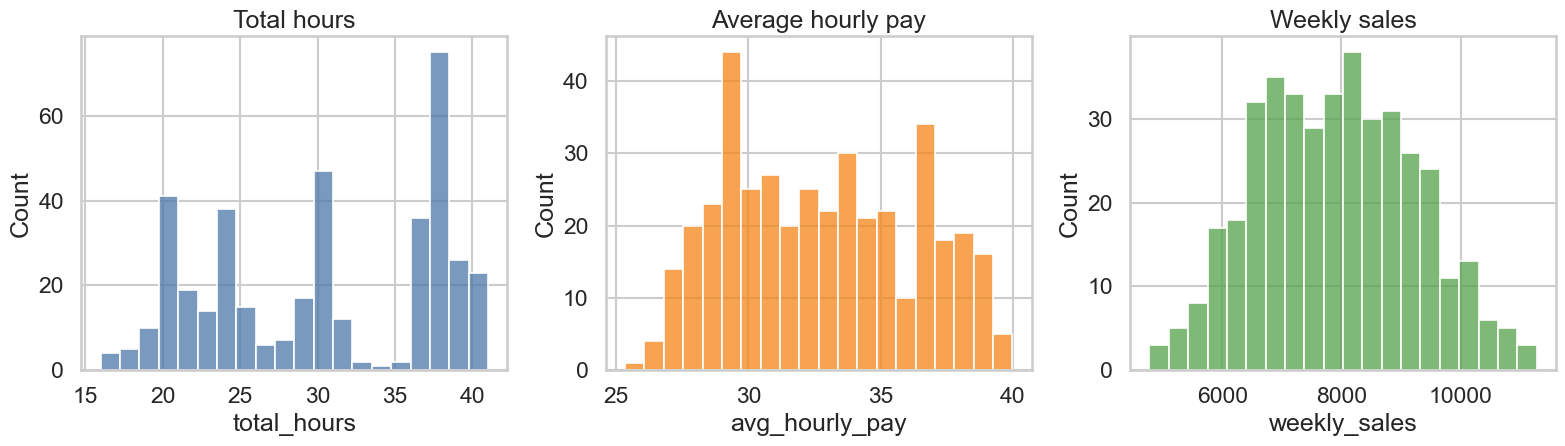

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

sns.histplot(df, x="total_hours", bins=20, color="#4C78A8", ax=axes[0])
axes[0].set_title("Total hours")

sns.histplot(df, x="avg_hourly_pay", bins=20, color="#F58518", ax=axes[1])
axes[1].set_title("Average hourly pay")

sns.histplot(df, x="weekly_sales", bins=20, color="#54A24B", ax=axes[2])
axes[2].set_title("Weekly sales")

fig.tight_layout()
fig.savefig(output_dir / "01_numeric_distributions.png", dpi=200, bbox_inches="tight")
plt.show()


`total_hours` shows bunching at common staffing levels, which is plausible if rosters are built around standard shifts. `avg_hourly_pay` has signs of rounding. `weekly_sales` is more dispersed and slightly right-skewed.


## Part 3: Composition of a Categorical Variable


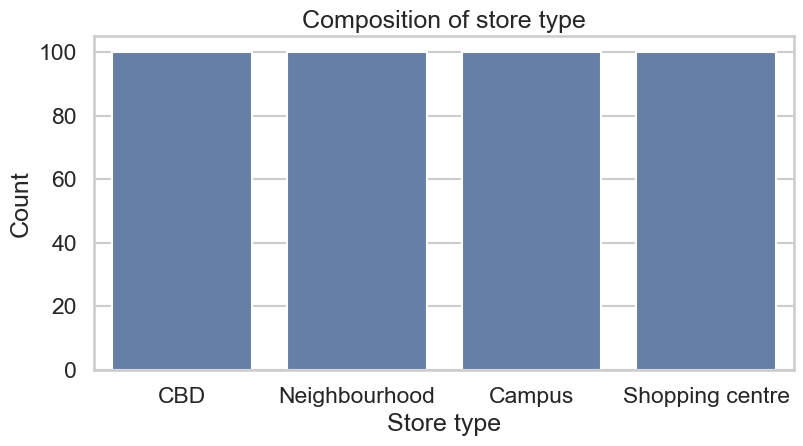

In [7]:
order = df["store_type"].value_counts().index

fig, ax = plt.subplots(figsize=(8.4, 4.8))
sns.countplot(data=df, x="store_type", order=order, color="#5B7DB1", ax=ax)
ax.set_title("Composition of store type")
ax.set_xlabel("Store type")
ax.set_ylabel("Count")
fig.tight_layout()
fig.savefig(output_dir / "02_store_type_composition.png", dpi=200, bbox_inches="tight")
plt.show()


The store types are fairly balanced in this teaching sample, which is useful because later comparisons are less likely to be driven by one category dominating the dataset.


## Part 4: Scatter Plots and Correlations


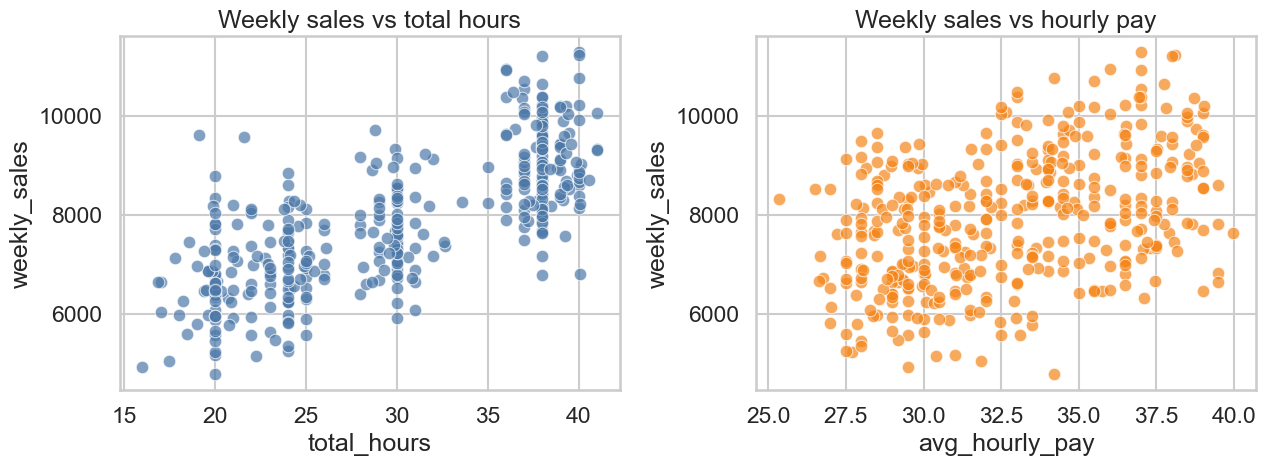

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(
    data=df,
    x="total_hours",
    y="weekly_sales",
    alpha=0.7,
    color="#4C78A8",
    ax=axes[0],
)
axes[0].set_title("Weekly sales vs total hours")

sns.scatterplot(
    data=df,
    x="avg_hourly_pay",
    y="weekly_sales",
    alpha=0.7,
    color="#F58518",
    ax=axes[1],
)
axes[1].set_title("Weekly sales vs hourly pay")

fig.tight_layout()
fig.savefig(output_dir / "03_scatterplots.png", dpi=200, bbox_inches="tight")
plt.show()


In [9]:
corr_vars = ["total_hours", "avg_hourly_pay", "weekly_sales"]

pearson_corr = df[corr_vars].corr(method="pearson").round(2)
spearman_corr = df[corr_vars].corr(method="spearman").round(2)

pearson_corr, spearman_corr


(                total_hours  avg_hourly_pay  weekly_sales
 total_hours            1.00           -0.01          0.75
 avg_hourly_pay        -0.01            1.00          0.41
 weekly_sales           0.75            0.41          1.00,
                 total_hours  avg_hourly_pay  weekly_sales
 total_hours            1.00           -0.02          0.74
 avg_hourly_pay        -0.02            1.00          0.40
 weekly_sales           0.74            0.40          1.00)

`weekly_sales` and `total_hours` are positively associated in both the scatter plot and the correlation tables. The relationship with `avg_hourly_pay` is weaker, which is also visible in the cloud of points.


## Part 5: Change the Scale


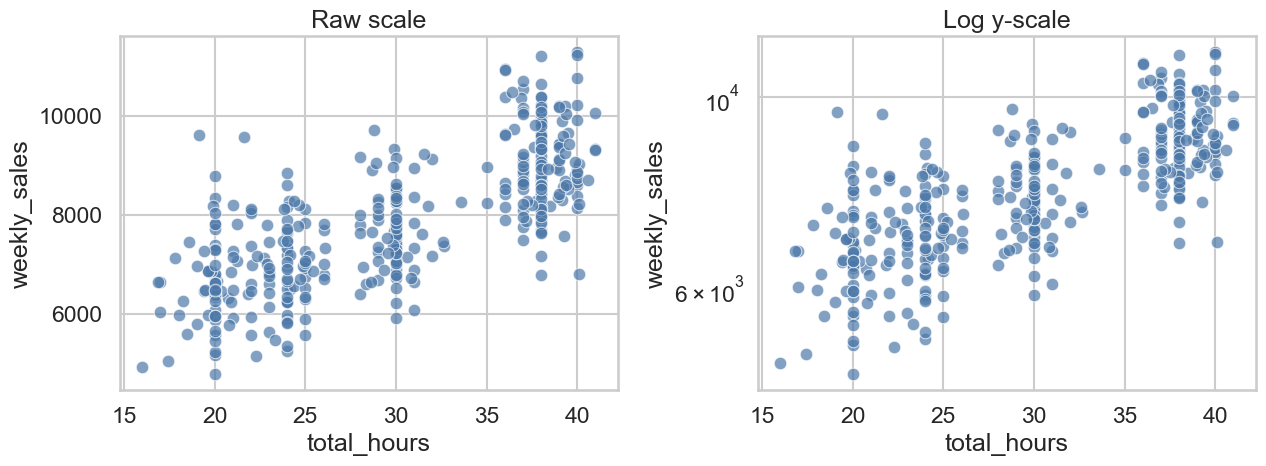

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True)

sns.scatterplot(
    data=df,
    x="total_hours",
    y="weekly_sales",
    alpha=0.7,
    color="#4C78A8",
    ax=axes[0],
)
axes[0].set_title("Raw scale")

sns.scatterplot(
    data=df,
    x="total_hours",
    y="weekly_sales",
    alpha=0.7,
    color="#4C78A8",
    ax=axes[1],
)
axes[1].set_yscale("log")
axes[1].set_title("Log y-scale")

fig.tight_layout()
fig.savefig(output_dir / "04_scale_comparison.png", dpi=200, bbox_inches="tight")
plt.show()


The log scale compresses the higher-sales observations and makes proportional differences easier to compare across the range of sales values.


## Part 6: Plot by Group


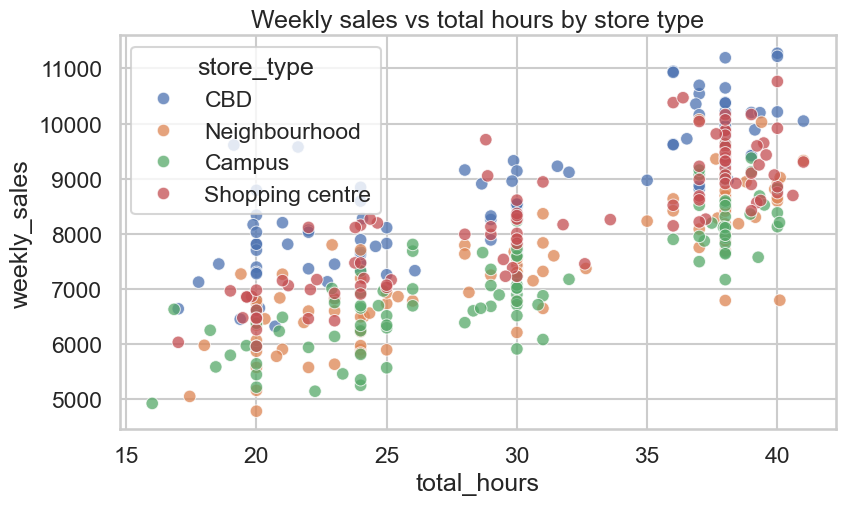

In [11]:
fig, ax = plt.subplots(figsize=(8.8, 5.4))
sns.scatterplot(
    data=df,
    x="total_hours",
    y="weekly_sales",
    hue="store_type",
    alpha=0.75,
    ax=ax,
)
ax.set_title("Weekly sales vs total hours by store type")
fig.tight_layout()
fig.savefig(output_dir / "05_scatter_by_group.png", dpi=200, bbox_inches="tight")
plt.show()


Splitting by `store_type` suggests that stores with similar staffing levels may still sit in different parts of the sales distribution. That is useful context before any later regression work.


## Part 7: README Draft


In [12]:
readme_draft = '''
## Analysis Summary

- The repository contains one cleaned teaching dataset, two notebooks, and an output folder for figures.
- `total_hours` shows bunching at common staffing levels and `avg_hourly_pay` appears somewhat rounded.
- `weekly_sales` rises with `total_hours`, with a clear positive association in both the scatter plot and the correlations.
- Changing the y-scale helps make the relationship easier to compare across the full sales range.
- Grouped plots suggest store type may matter even after accounting for staffing levels.
'''.strip()

print(readme_draft)


## Analysis Summary

- The repository contains one cleaned teaching dataset, two notebooks, and an output folder for figures.
- `total_hours` shows bunching at common staffing levels and `avg_hourly_pay` appears somewhat rounded.
- `weekly_sales` rises with `total_hours`, with a clear positive association in both the scatter plot and the correlations.
- Changing the y-scale helps make the relationship easier to compare across the full sales range.
- Grouped plots suggest store type may matter even after accounting for staffing levels.
